## Historical Analysis and Econometric Modeling of Global Aviation Accidents (1908–2009)

**Project Objective**
The objective of this project is to conduct a comprehensive empirical analysis of historical aviation accidents since 1908. The study aims to perform data preprocessing, identify long-term temporal trends across years and months, determine the highest-risk aircraft operators, and deploy an Ordinary Least Squares (OLS) regression model to mathematically evaluate the statistical relationship between the number of individuals aboard and the resulting fatalities.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import datetime

In [3]:
data = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

# Color palette
VERDIGRIS = '#40B5AD'
LIGHT_PINK ='#FFB6C1'

### Phase 1: Data Cleaning and Preprocessing

To ensure the integrity of our statistical and econometric analysis, we perform systematic data cleaning. This involves inspecting the structural layout, handling missing (null) values, filtering out rows with critical missing features, and engineering new temporal variables.

In [4]:
def display_dataset_overview(df):
    """Prints structural information and the first few rows of the dataset."""
    print("Dataset Structural Overview:")
    display(df.info())
    print("\nFirst 5 Rows of the Dataset:")
    display(df.head())

# Execute baseline structural overview
display_dataset_overview(data)

Dataset Structural Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         5268 non-null   int64  
 1   Date          5268 non-null   object 
 2   Time          3049 non-null   object 
 3   Location      5248 non-null   object 
 4   Operator      5250 non-null   object 
 5   Flight #      1069 non-null   object 
 6   Route         3561 non-null   object 
 7   Type          5241 non-null   object 
 8   Registration  4933 non-null   object 
 9   cn/In         4040 non-null   object 
 10  Aboard        5246 non-null   float64
 11  Fatalities    5256 non-null   float64
 12  Ground        5246 non-null   float64
 13  Summary       4878 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 576.3+ KB


None


First 5 Rows of the Dataset:


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [5]:
def check_missing_data(df):
    """Outputs the summation of null values across all columns."""
    print("\nMissing Values Count Per Column:")
    print(df.isnull().sum())

# Check for missing values in raw data
check_missing_data(data)


Missing Values Count Per Column:
index              0
Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64


In [6]:
# Drop rows where critical analytical target variables are missing
df_cleaned = data.dropna(subset=['Date', 'Aboard', 'Fatalities', 'Ground']).copy()
print(f"\nDataset size after removing critical missing rows: {df_cleaned.shape[0]} rows")

# Impute missing categorical values with 'Unknown' placeholder
df_cleaned.loc[:, 'Flight #'] = df_cleaned['Flight #'].fillna('Unknown')
df_cleaned.loc[:, 'Route'] = df_cleaned['Route'].fillna('Unknown')
df_cleaned.loc[:, 'Registration'] = df_cleaned['Registration'].fillna('Unknown')
df_cleaned.loc[:, 'Time'] = df_cleaned['Time'].fillna('Unknown')
df_cleaned.loc[:, 'Type'] = df_cleaned['Type'].fillna('Unknown')
df_cleaned.loc[:, 'Summary'] = df_cleaned['Summary'].fillna('Unknown')

# Exclude specific serial/identification columns not required for the macro analysis
if 'cn/In' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['cn/In'])

# Verify remaining missing values
print("\nRemaining Missing Values Check:")
print(df_cleaned.isnull().sum())


Dataset size after removing critical missing rows: 5236 rows

Remaining Missing Values Check:
index            0
Date             0
Time             0
Location        19
Operator        18
Flight #         0
Route            0
Type             0
Registration     0
Aboard           0
Fatalities       0
Ground           0
Summary          0
dtype: int64


In [7]:
# Convert 'Date' column to datetime format, turning invalid formats to NaT
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce')

# Drop any rows where the date conversion failed
df_cleaned = df_cleaned.dropna(subset=['Date'])

# Isolate Year and Month variables for longitudinal trend analysis
df_cleaned.loc[:, 'Year'] = df_cleaned['Date'].dt.year
df_cleaned.loc[:, 'Month'] = df_cleaned['Date'].dt.month

# Preview preprocessed dataset features
print("\nProcessed Data Sample Preview:")
display(df_cleaned.head())


Processed Data Sample Preview:


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,Aboard,Fatalities,Ground,Summary,Year,Month
0,0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,Unknown,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9
1,1,1912-07-12,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7
2,2,1913-08-06,Unknown,"Victoria, British Columbia, Canada",Private,-,Unknown,Curtiss seaplane,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8
3,3,1913-09-09,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913,9
4,4,1913-10-17,10:30,"Near Johannisthal, Germany",Military - German Navy,Unknown,Unknown,Zeppelin L-2 (airship),Unknown,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913,10


### Phase 2: Exploratory Data Analysis (EDA) & Visualization

We build customized visualizations to understand trends, accident distributions, and frequency across different dimensions.

#### **2.1: Annual Accident Distribution**



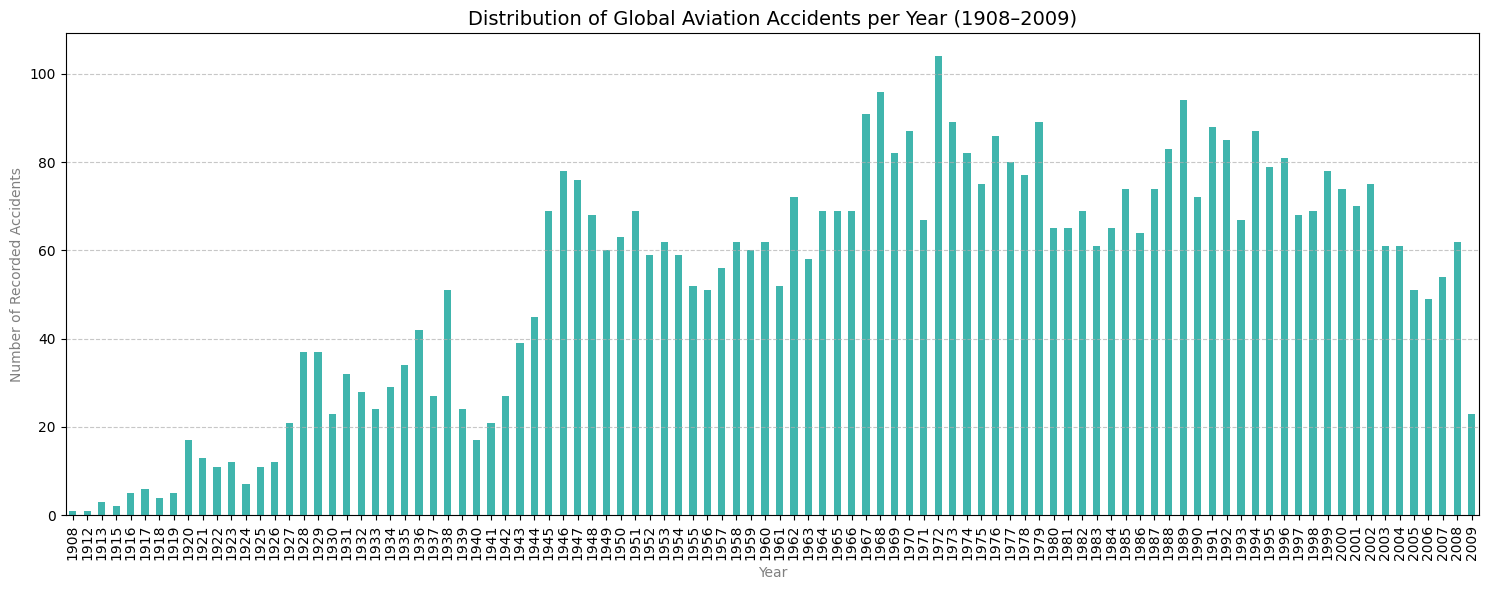

In [8]:
def plot_accidents_per_year(df):
    """Generates a bar plot indicating historical frequency of crashes per annum."""
    plt.figure(figsize=(15, 6))
    df['Year'].value_counts().sort_index().plot(kind='bar', color=VERDIGRIS)
    plt.title('Distribution of Global Aviation Accidents per Year (1908–2009)', fontsize=14)
    plt.xlabel('Year', color='grey')
    plt.ylabel('Number of Recorded Accidents', color='grey')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_accidents_per_year(df_cleaned)

#### **2.2: Fatality Metric Formulation and Safety Scaling**

In [9]:
# Construct a relative scale representing the proportion of lives lost relative to total capacity
df_cleaned.loc[:, 'Fatality_Rate'] = df_cleaned['Fatalities'] / df_cleaned['Aboard']
df_cleaned.loc[:, 'Fatality_Rate'] = df_cleaned['Fatality_Rate'].fillna(0)

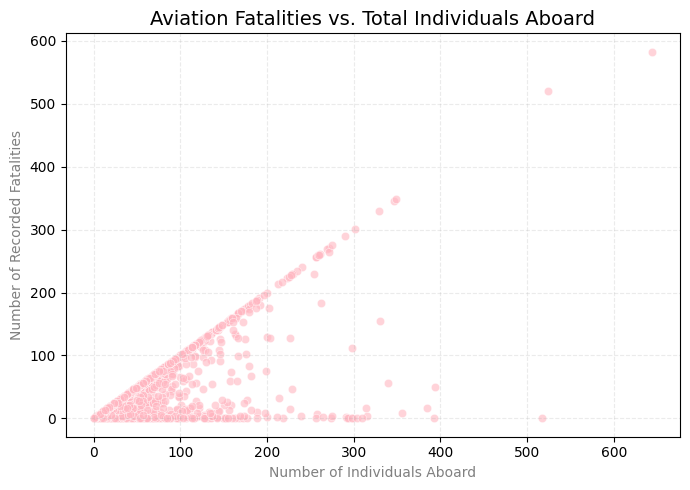

In [10]:
def plot_fatalities_vs_aboard(df):
    """Plots relationship between individuals aboard and total recorded fatalities."""
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x='Aboard', y='Fatalities', data=df, alpha=0.6, color=LIGHT_PINK)
    plt.title('Aviation Fatalities vs. Total Individuals Aboard', fontsize=14)
    plt.xlabel('Number of Individuals Aboard', color='grey')
    plt.ylabel('Number of Recorded Fatalities', color='grey')
    plt.grid(axis='both', linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_fatalities_vs_aboard(df_cleaned)

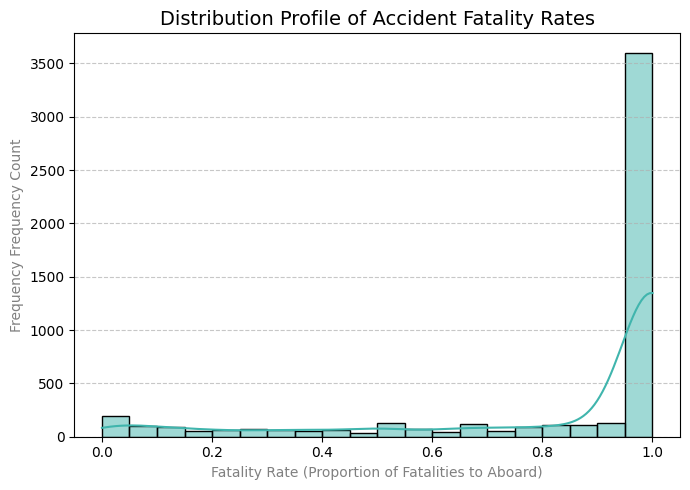

In [11]:
def plot_fatality_rate_distribution(df):
    """Visualizes the concentration and probability density distribution of accident fatality rates."""
    plt.figure(figsize=(7, 5))
    sns.histplot(df['Fatality_Rate'], kde=True, bins=20, color=VERDIGRIS)
    plt.title('Distribution Profile of Accident Fatality Rates', fontsize=14)
    plt.xlabel('Fatality Rate (Proportion of Fatalities to Aboard)', color='grey')
    plt.ylabel('Frequency Frequency Count', color='grey')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_fatality_rate_distribution(df_cleaned)

#### **2.3: Operator Risk Profiling**

In [12]:
def get_top_operators(df):
    """Identifies and returns the top 10 aircraft operators with the highest absolute accident count."""
    operator_accident_counts = df['Operator'].value_counts().head(10)
    print("\nTop 10 Operators with the Highest Number of Recorded Accidents:")
    print(operator_accident_counts)
    return operator_accident_counts

top_operators_series = get_top_operators(df_cleaned)


Top 10 Operators with the Highest Number of Recorded Accidents:
Operator
Aeroflot                           179
Military - U.S. Air Force          174
Air France                          67
Deutsche Lufthansa                  65
Air Taxi                            44
United Air Lines                    43
Military - U.S. Army Air Forces     43
Pan American World Airways          40
US Aerial Mail Service              36
Military - U.S. Navy                36
Name: count, dtype: int64


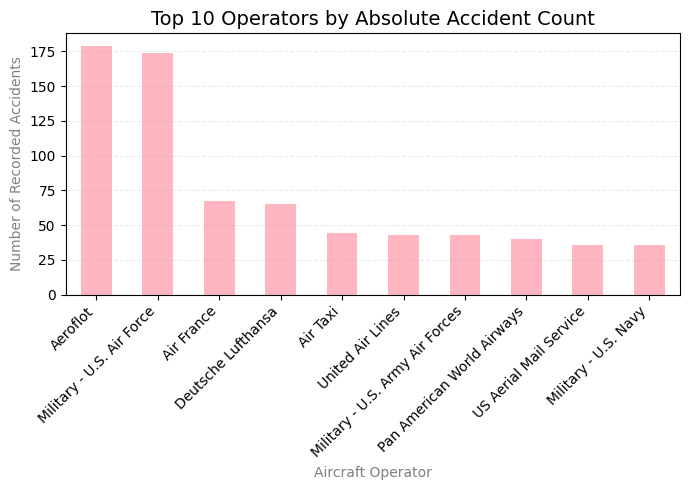

In [13]:
def plot_top_operators(operator_counts):
    """Bar plot representing operational accident distributions across key operators."""
    plt.figure(figsize=(7, 5))
    operator_counts.plot(kind='bar', color=LIGHT_PINK)
    plt.title('Top 10 Operators by Absolute Accident Count', fontsize=14)
    plt.xlabel('Aircraft Operator', color='grey')
    plt.ylabel('Number of Recorded Accidents', color='grey')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_top_operators(top_operators_series)

#### **2.4: Seasonal Variation and Monthly Fluctuations**

In [14]:
def compute_monthly_accidents(df):
    """Aggregates absolute number of historical accidents isolated by calendar month."""
    monthly_counts = {}
    for month in range(1, 13):
        monthly_counts[month] = df[df['Month'] == month].shape[0]
    return monthly_counts

monthly_accidents_dict = compute_monthly_accidents(df_cleaned)

print("\nAggregate Distribution of Aviation Accidents Across Months:")
for month, count in monthly_accidents_dict.items():
    print(f"Month {month}: {count} recorded accidents")


Aggregate Distribution of Aviation Accidents Across Months:
Month 1: 494 recorded accidents
Month 2: 393 recorded accidents
Month 3: 450 recorded accidents
Month 4: 377 recorded accidents
Month 5: 368 recorded accidents
Month 6: 384 recorded accidents
Month 7: 427 recorded accidents
Month 8: 472 recorded accidents
Month 9: 457 recorded accidents
Month 10: 452 recorded accidents
Month 11: 449 recorded accidents
Month 12: 513 recorded accidents


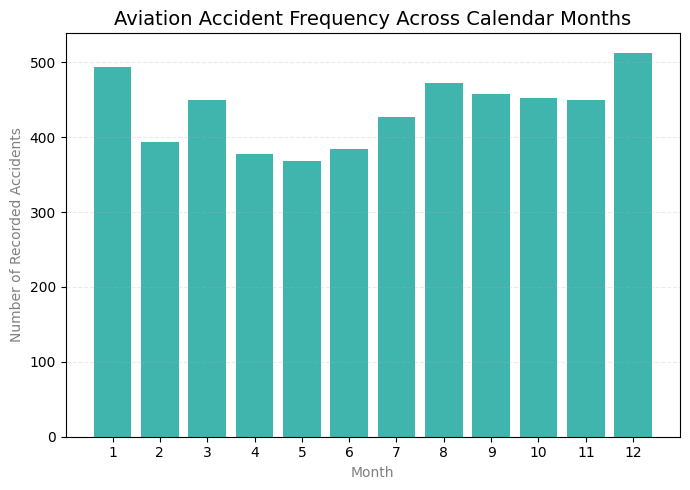

In [15]:
def plot_accidents_per_month(monthly_data):
    """Plots seasonal variation of historical aviation accidents."""
    plt.figure(figsize=(7, 5))
    plt.bar(monthly_data.keys(), monthly_data.values(), color=VERDIGRIS)
    plt.title('Aviation Accident Frequency Across Calendar Months', fontsize=14)
    plt.xlabel('Month', color='grey')
    plt.ylabel('Number of Recorded Accidents', color='grey')
    plt.grid(axis='y', linestyle='--', alpha=0.25)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

plot_accidents_per_month(monthly_accidents_dict)

### Phase 3: Econometric and Statistical Inference
This segment establishes baseline quantitative behavior by reviewing statistical characteristics, computing Pearson correlation values, and fitting an Ordinary Least Squares linear regression model.

In [16]:
def display_statistical_summary(df):
    """Outputs basic descriptive statistics for capacity, fatalities, and fatality scale."""
    print("\nDescriptive Statistical Summary Table:")
    print(df[['Aboard', 'Fatalities', 'Fatality_Rate']].describe())

display_statistical_summary(df_cleaned)


Descriptive Statistical Summary Table:
            Aboard   Fatalities  Fatality_Rate
count  5236.000000  5236.000000    5236.000000
mean     27.589190    20.104851       0.834404
std      43.109636    33.238341       0.299317
min       0.000000     0.000000       0.000000
25%       5.000000     3.000000       0.800000
50%      13.000000     9.000000       1.000000
75%      30.000000    23.000000       1.000000
max     644.000000   583.000000       1.000000


#### **3.1 Ordinary Least Squares (OLS) Linear Regression**
We formulate an empirical specification to evaluate the baseline elasticities/marginal effects of total capacity (Aboard) acting as our independent variable to explain the variations within the dependent variable (Fatalities).

In [17]:
# Define endogenous and exogenous modeling components
X = df_cleaned[['Aboard']]
y = df_cleaned['Fatalities']

# Fit an Ordinary Least Squares (OLS) estimation model
ols_regression_model = sm.OLS(y, X).fit()

def display_ols_results(model):
    """Prints the comprehensive parameters and diagnostics output of the fitted OLS specification."""
    print("\nOrdinary Least Squares (OLS) Regression Results Summary:")
    print(model.summary())

display_ols_results(ols_regression_model)


Ordinary Least Squares (OLS) Regression Results Summary:
                                 OLS Regression Results                                
Dep. Variable:             Fatalities   R-squared (uncentered):                   0.680
Model:                            OLS   Adj. R-squared (uncentered):              0.680
Method:                 Least Squares   F-statistic:                          1.113e+04
Date:                Thu, 28 May 2026   Prob (F-statistic):                        0.00
Time:                        08:37:55   Log-Likelihood:                         -23608.
No. Observations:                5236   AIC:                                  4.722e+04
Df Residuals:                    5235   BIC:                                  4.722e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0

#### **3.2 Correlation Configuration Analysis**


In [18]:
def compute_correlation_matrix(df):
    """Computes the linear correlation coefficients across key continuous dimensions."""
    corr_matrix = df[['Aboard', 'Fatalities', 'Fatality_Rate']].corr()
    print("\nPearson Linear Correlation Matrix:")
    print(corr_matrix)
    return corr_matrix

correlation_matrix_df = compute_correlation_matrix(df_cleaned)


Pearson Linear Correlation Matrix:
                 Aboard  Fatalities  Fatality_Rate
Aboard         1.000000    0.757101      -0.226003
Fatalities     0.757101    1.000000       0.186892
Fatality_Rate -0.226003    0.186892       1.000000


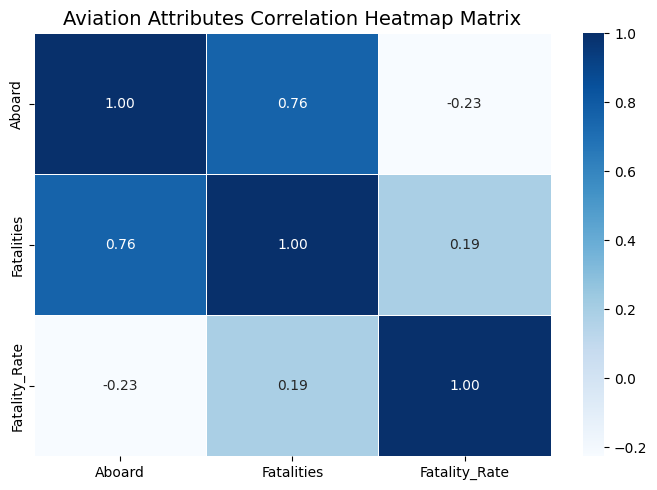

In [19]:
def plot_correlation_heatmap(corr_matrix):
    """Visualizes the correlation coefficient matrix via a customized heatmap."""
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
    plt.title('Aviation Attributes Correlation Heatmap Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(correlation_matrix_df)

In [20]:
df_cleaned.to_csv('dataset_cleaned.csv', index=False)
print("Data frame successfully exported and saved as 'dataset_cleaned.csv'.")

Data frame successfully exported and saved as 'dataset_cleaned.csv'.


### Phase 5: Project Conclusion and Key Findings
Based on the empirical analysis of the historical aviation accidents dataset (comprising 5,236 validated records after cleaning), several significant statistical and operational insights were identified:

1. Operational Risk Profile
*   Most Frequent Operators: The highest absolute number of historical crashes was recorded by Aeroflot (179 incidents) and the Military - U.S. Air Force (174 incidents). It is important to note that these high counts are partly reflective of the sheer volume of flights these entities operated historically, as well as the inherently risky nature of historical military and early commercial aviation.
*   Monthly Trends: Aviation accidents show observable seasonal variation. December (513 crashes) and January (494 crashes) are historically the months with the highest frequency of accidents, potentially suggesting that adverse winter weather conditions in the Northern Hemisphere play a contributing role in aviation risk.

2. Fatality Distribution
*   High Lethality of Accidents: The average fatality rate across all crashes is extremely high at 83.4% (Mean Fatality_Rate = 0.834). The median (50th percentile) fatality rate is exactly 1.0, indicating that in more than half of all recorded accidents, there were no survivors among the passengers and crew.
*   Descriptive Statistics: On average, an aircraft involved in an accident carried roughly 28 people (mean = 27.59), with an average of 20 fatalities per crash.
3. Econometric Relationship (OLS & Correlation)
*   Strong Positive Correlation: There is a strong positive Pearson correlation (r = 0.757) between the number of individuals aboard and the total fatalities, which is intuitively expected. Interestingly, there is a slight negative correlation (r = -0.226) between the number of people aboard and the Fatality Rate, suggesting a marginal tendency for larger aircraft to have slightly higher proportional survival rates during an incident.
*   OLS Regression Output: The baseline Ordinary Least Squares model estimating Fatalities based purely on Aboard yielded an R-squared of 0.6800. The estimated coefficient is 0.626. In practical terms, this implies that for every 10 individuals aboard an aircraft involved in an accident, the model statistically predicts approximately 6 fatalities. While this provides a baseline expected value, the high variance in real-world crashes (ranging from 100% survival to 100% fatality) means other exogenous variables (such as weather, plane model, and pilot error) are necessary for a fully specified predictive model.

**Final Summary:** The analysis successfully highlights the historical reduction in aviation risks over decades, the concentration of crashes among specific large-scale operators, and mathematically confirms the lethality of aviation failures. Future extensions of this project could involve integrating weather datasets and utilizing time-series forecasting to predict future safety trends.